In [23]:
import qutip as qt
from qutip import *
import matplotlib.pyplot as plt
import numpy as np

In [24]:
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import quad
from scipy.special import gamma, zeta, eval_hermite, factorial

# Define parameters
kappa = 2.5e-3*2*np.pi*2

# Define sech function
def sech(x):
    return 1 / np.cosh(x)

_kappa_cache = {}

def _N_m(m, kappa):
    numerator = 8 * (1 - 2**(1 - 2*m)) * gamma(2*m + 1) * zeta(2*m)
    denominator = kappa**(2*m + 1)
    return 1.0 / (numerator / denominator)

def _compute_Z_m(m, A_coeffs, kappa):
    Z = 0.0
    for k in range(m // 2 + 1):
        deg_k = m - 2 * k
        A_k = A_coeffs[deg_k]
        inner_sum = 0.0
        for l in range(m // 2 + 1):
            deg_l = m - 2 * l
            A_l = A_coeffs[deg_l]
            Nj_index = m - (k + l)
            Nj = _N_m(Nj_index, kappa)
            inner_sum += A_l / Nj
        Z += A_k * inner_sum
    return 1 / Z

def _get_A_m(m, kappa):
    if kappa not in _kappa_cache:
        _kappa_cache[kappa] = {
            "A_list": {0: [1.0]},
            "Z_dict": {0: kappa / 4},
        }

    A_list = _kappa_cache[kappa]["A_list"]
    Z_dict = _kappa_cache[kappa]["Z_dict"]

    if m in A_list:
        return A_list[m]

    A_m_coeffs = [0.0] * (m + 1)
    A_m_coeffs[m] = 1.0

    for i in range(1, m // 2 + 1):
        lower_m = m - 2 * i
        A_lower = _get_A_m(lower_m, kappa)

        inner_sum = 0.0
        for j in range(0, (m // 2 - i) + 1):
            index_in_A = m - 2 * (i + j)
            if 0 <= index_in_A < len(A_lower):
                A_coeff = A_lower[index_in_A]
                Nj = _N_m(m - (i + j), kappa)
                inner_sum += A_coeff / Nj

        Z = Z_dict.get(lower_m, 1.0)
        for power, coeff in enumerate(A_lower):
            if power < len(A_m_coeffs):
                A_m_coeffs[power] -= inner_sum * Z * coeff

    Z_m = _compute_Z_m(m, A_m_coeffs, kappa)
    Z_dict[m] = Z_m
    A_list[m] = A_m_coeffs
    return A_m_coeffs

def xi_m(t, m, kappa):
    A_coeffs = _get_A_m(m, kappa)
    Zm = _kappa_cache[kappa]["Z_dict"][m]
    A_val = sum(c * t**i for i, c in enumerate(A_coeffs))
    return np.sqrt(Zm) * sech(kappa * t / 2) * A_val

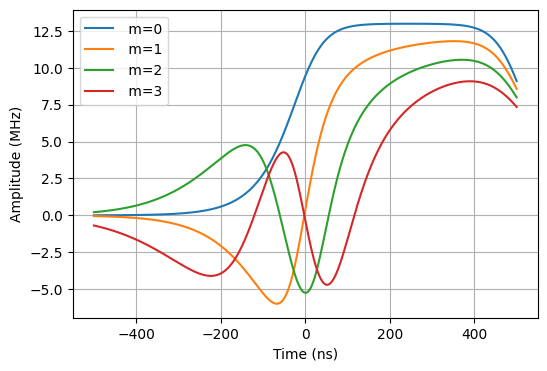

In [25]:

def f(t, m, kappa):
    return xi_m(t, m, kappa)

def f_prime(t, m, kappa, h=1e-3):
    return (f(t + h, m, kappa) - f(t - h, m, kappa)) / (2 * h)

def compute_g(t_vals, m, kappa, kappa_ph):
    f_vals = f(t_vals, m, kappa_ph)
    f_prime_vals = f_prime(t_vals, m, kappa_ph)
    

    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, t_vals, initial=0)
    
    numerator = f_prime_vals + (kappa * f_vals / 2)
    denominator = np.sqrt(kappa * (1 - integral_vals) - f2_vals)
    
    return numerator / denominator

kappa =  0.14*2*np.pi
kappa_ph = 2.5e-3*2*np.pi*2
t_vals = np.linspace(-500, 500, 501)

plt.figure(figsize=(6, 4))
for m in range(4):
    g_vals = compute_g(t_vals, m, kappa, kappa_ph)
    plt.plot(t_vals, np.real(g_vals)/2/np.pi*1e3, label=fr" m={m}")

plt.xlabel("Time (ns)")
plt.ylabel("Amplitude (MHz)")
plt.legend()
plt.grid(True)
plt.show()


In [26]:
n_cutoff_q = 3
n_cutoff_r = 2
n_cutoff_vc = 3

b = qt.tensor(qt.destroy(n_cutoff_q), qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
a = qt.tensor(qt.qeye(n_cutoff_q), qt.destroy(n_cutoff_r), qt.qeye(n_cutoff_vc))
vc = qt.tensor(qt.qeye(n_cutoff_q), qt.qeye(n_cutoff_r), qt.destroy(n_cutoff_vc))

zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,1]=1
gedecayop=Qobj(zeromatrixxtmp)
etog = qt.tensor(gedecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,2]=1
efdecayop=Qobj(zeromatrixxtmp)
ftoe = qt.tensor(efdecayop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[0,0]=-1
zeromatrixxtmp[1,1]=1
gedechoop=Qobj(zeromatrixxtmp)
dechoge = qt.tensor(gedechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))
zeromatrixxtmp=np.zeros([n_cutoff_q, n_cutoff_q])
zeromatrixxtmp[1,1]=-1
zeromatrixxtmp[2,2]=1
efdechoop=Qobj(zeromatrixxtmp)
dechoef = qt.tensor(efdechoop, qt.qeye(n_cutoff_r), qt.qeye(n_cutoff_vc))

g0 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
f0 = qt.tensor(qt.basis(n_cutoff_q, 2), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
g1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 1), qt.basis(n_cutoff_vc, 0))
e0 = qt.tensor(qt.basis(n_cutoff_q, 1), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 0))
vc1 = qt.tensor(qt.basis(n_cutoff_q, 0), qt.basis(n_cutoff_r, 0), qt.basis(n_cutoff_vc, 1))

alpha = -0.356 * 2 * np.pi
chi = -0.0076 * 2 * np.pi
eta = 0.67
kappa_r = 0.14 * 2 * np.pi
K = 0 * 2 * np.pi

H_fogi = (
    -alpha / 2 * b.dag()*b + alpha * b.dag()*b.dag()*b*b / 2
    +K * a.dag()*a.dag()*a*a / 2 + 2*chi*a.dag()*a*b.dag()*b
)

H_d = -a.dag()*b*b/np.sqrt(2)
H_c = 1j * (np.sqrt(kappa_r)/2) * vc.dag()*a

T1ge=29*1e3
T1ef=22*1e3
T2ge=5*1e3
T2ef=5*1e3
Tphige=1/((1/T2ge-1/T1ge/2)/2)
Tphief=1/((1/T2ef-1/T1ef/2)/2)

e_ops = []
options = Options(store_states=True, store_final_state=False, nsteps=1000, progress_bar=True)

c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


In [27]:
from scipy.integrate import cumulative_trapezoid
from scipy.interpolate import interp1d

T = 500 
N = 251
tgrid = np.linspace(-T, T, N)
dt = tgrid[1] - tgrid[0]
kappa_ph = 2.5e-3 * 2 * np.pi * 2

_eps = 1e-14

g_interps = []
g_interps_rvs = []

for m in range(4): 
    f_vals = f(tgrid, m, kappa_ph)
    f_prime_vals = f_prime(tgrid, m, kappa_ph) 
    f2_vals = np.abs(f_vals)**2
    integral_vals = cumulative_trapezoid(f2_vals, tgrid, initial=0)

    numerator = f_prime_vals + (kappa_r * f_vals / 2)
    denominator = np.sqrt(kappa_r * (1.0 - integral_vals) - f2_vals)
    g_vals = numerator / denominator
    g_interp = interp1d(tgrid, np.real(g_vals), kind='cubic', fill_value='extrapolate')
    g_interps.append(g_interp)

    g_interp_rvs = interp1d(tgrid, np.real(g_vals[::-1]), kind='cubic', fill_value='extrapolate') 
    g_interps_rvs.append(g_interp_rvs)
    
g_u_interps = []
for m in range(4):
    ut_vals = xi_m(tgrid, m, kappa_ph)
    cumint = cumulative_trapezoid(np.abs(ut_vals)**2, tgrid, initial=0)
    eps = 1e-14
    denom = np.sqrt(1.0 - cumint + eps)
    g_vals = np.conjugate(ut_vals) / denom
    g_interp = interp1d(tgrid, g_vals, kind='cubic', fill_value='extrapolate')
    g_u_interps.append(g_interp)

def g_u(t, args):
    m = int(args["input_num"])
    t_local = float(t)
    return float(args["g_u_interps"][m](t_local))

def g_u_conj(t, args):
    return np.conjugate(g_u(t, args))

def g_time(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps"][m](t_local))

def g_time_conj(t, args):
    return np.conjugate(g_time(t, args))

def g_time_rvs(t, args):
    t_local = float(t) - float(args["center"])
    m = int(args["fogi_mode"])
    # access interpolant precomputed above (we'll pass lists via args)
    return float(args["g_interps_rvs"][m](t_local))

def g_time_conj_rvs(t, args):
    return np.conjugate(g_time_rvs(t, args))

In [24]:
base_args = {
    "center": 0.0,
    "fogi_mode": 2,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 0,
}
results = {} 

for m in range(4):
    args_m = base_args.copy()
    args_m["fogi_mode"] = m

    H_m = [
        H_fogi,
        [H_d, g_time], [H_d.dag(), g_time_conj],
    ]
    psi0_m = (g0 + f0).unit()


    def total_c_op(t, args):
        c_op = np.sqrt(kappa_r) * a
        return c_op

    c_ops_m = [
        total_c_op,
        np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
        np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
    ]

    result_m = qt.mesolve(
        H_m, psi0_m, tgrid, c_ops_m, e_ops=e_ops,
        args=args_m, options=options, progress_bar=True
    )

    results[m] = result_m
    print(f"mode {m} finished")
# Extract states

10.0%. Run time:   0.08s. Est. time left: 00:00:00:00
20.0%. Run time:   0.18s. Est. time left: 00:00:00:00
30.0%. Run time:   0.28s. Est. time left: 00:00:00:00
40.0%. Run time:   0.37s. Est. time left: 00:00:00:00
50.0%. Run time:   0.47s. Est. time left: 00:00:00:00
60.0%. Run time:   0.57s. Est. time left: 00:00:00:00
70.0%. Run time:   0.68s. Est. time left: 00:00:00:00
80.0%. Run time:   0.89s. Est. time left: 00:00:00:00
90.0%. Run time:   0.97s. Est. time left: 00:00:00:00
100.0%. Run time:   1.07s. Est. time left: 00:00:00:00
Total run time:   1.07s
mode 0 finished
10.0%. Run time:   0.14s. Est. time left: 00:00:00:01
20.0%. Run time:   0.26s. Est. time left: 00:00:00:01
30.0%. Run time:   0.39s. Est. time left: 00:00:00:00
40.0%. Run time:   0.51s. Est. time left: 00:00:00:00
50.0%. Run time:   0.63s. Est. time left: 00:00:00:00
60.0%. Run time:   0.76s. Est. time left: 00:00:00:00
70.0%. Run time:   0.88s. Est. time left: 00:00:00:00
80.0%. Run time:   0.95s. Est. time left:

In [29]:

# ---------------------------
# Parameters
# ---------------------------
psi0 = (g0 + f0).unit()

args = {
    "center": 0.0,
    "fogi_mode": 3,
    "g_interps": g_interps,
    "g_interps_rvs": g_interps_rvs,
    "g_u_interps": g_u_interps,
    "input_num": 0,
    "input": 0,
}

# L_func/L_dag_func は同じものを返す
def L_func(t, args):
    return np.sqrt(kappa_r) * a

def L_dag_func(t, args):
    return np.sqrt(kappa_r) * a.dag()

# ---------------------------
# mesolveで瞬時光子数
# ---------------------------
H = [
    H_fogi,
    [H_d, g_time], [H_d.dag(), g_time_conj],
]
def total_c_op(t, args):
    c_op = np.sqrt(kappa_r) * a
    return c_op

c_ops = [
    total_c_op,
    np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
    np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
]
result = qt.mesolve(H, psi0, tgrid, c_ops, e_ops=[a.dag() * a], args=args, options=options, progress_bar=True)
n_meso = result.expect[0]

# ---------------------------
# correlation_2op_2tでG1(t1, t2)
# ---------------------------
G1 = qt.correlation_2op_2t(
    H,
    psi0,
    tgrid,
    tgrid,
    c_ops,
    a.dag(),
    a,
    args=args,
    options=options
)


10.0%. Run time:   0.13s. Est. time left: 00:00:00:01
20.0%. Run time:   0.24s. Est. time left: 00:00:00:00
30.0%. Run time:   0.31s. Est. time left: 00:00:00:00
40.0%. Run time:   0.40s. Est. time left: 00:00:00:00
50.0%. Run time:   0.50s. Est. time left: 00:00:00:00
60.0%. Run time:   0.61s. Est. time left: 00:00:00:00
70.0%. Run time:   0.70s. Est. time left: 00:00:00:00
80.0%. Run time:   0.78s. Est. time left: 00:00:00:00
90.0%. Run time:   0.87s. Est. time left: 00:00:00:00
100.0%. Run time:   0.96s. Est. time left: 00:00:00:00
Total run time:   0.96s
10.3%. Run time:  17.56s. Est. time left: 00:00:02:32
20.2%. Run time:  36.62s. Est. time left: 00:00:02:24
30.2%. Run time:  77.84s. Est. time left: 00:00:03:00
40.1%. Run time: 104.25s. Est. time left: 00:00:02:35
50.0%. Run time: 130.63s. Est. time left: 00:00:02:10
60.3%. Run time: 141.40s. Est. time left: 00:00:01:33
70.2%. Run time: 151.44s. Est. time left: 00:00:01:04
80.2%. Run time: 162.91s. Est. time left: 00:00:00:40
90.

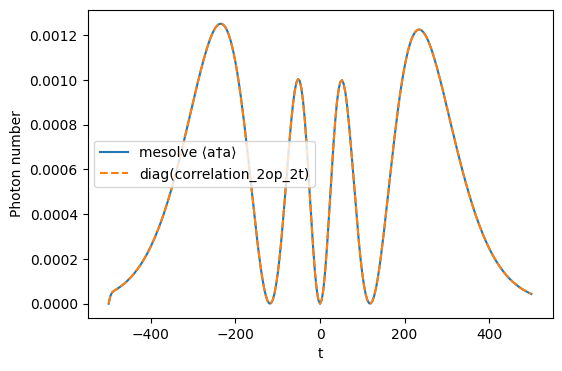

差の最大値: 2.208977065935175e-11


In [30]:
# 対角線を取得
n_corr = np.real(G1[:, 0])

# ---------------------------
# プロット比較
# ---------------------------
plt.figure(figsize=(6, 4))
plt.plot(tgrid, n_meso, label="mesolve ⟨a†a⟩")
plt.plot(tgrid, n_corr, "--", label="diag(correlation_2op_2t)")
plt.xlabel("t")
plt.ylabel("Photon number")
plt.legend()
plt.show()

# 一致を確認
print("差の最大値:", np.max(np.abs(n_meso - n_corr)))

In [30]:
results_output = {} 
for m in range(4):
    args_m = base_args.copy()
    args_m["fogi_mode"] = m

    H_m = [
        H_fogi,
        [H_d, g_time], [H_d.dag(), g_time_conj],
        ]
    
    c_ops_m = [
        total_c_op,
        np.sqrt(1/T1ge)*etog, np.sqrt(1/T1ef)*ftoe,
        np.sqrt(1/Tphige)*dechoge, np.sqrt(1/Tphief)*dechoef
    ]
    psi0_m = (g0 + f0).unit()
    G1 = qt.correlation_2op_2t(
        H_m,     
        psi0_m,
        tgrid,
        tgrid,
        c_ops_m,
        L_dag_func,
        L_func,
        args=args_m,
        options=options
    )

    results_output[m] = G1
    print(f"mode {m} finished")

10.3%. Run time:  15.18s. Est. time left: 00:00:02:11
20.2%. Run time:  28.66s. Est. time left: 00:00:01:52
30.2%. Run time:  42.88s. Est. time left: 00:00:01:39
40.1%. Run time:  67.45s. Est. time left: 00:00:01:40
50.0%. Run time:  94.68s. Est. time left: 00:00:01:34
60.3%. Run time: 111.88s. Est. time left: 00:00:01:13
70.2%. Run time: 141.42s. Est. time left: 00:00:00:59
80.2%. Run time: 170.20s. Est. time left: 00:00:00:42
90.1%. Run time: 181.33s. Est. time left: 00:00:00:19
100.0%. Run time: 193.48s. Est. time left: 00:00:00:00
Total run time: 193.48s
mode 0 finished
10.3%. Run time:  32.97s. Est. time left: 00:00:04:46
20.2%. Run time:  46.65s. Est. time left: 00:00:03:03
30.2%. Run time:  62.82s. Est. time left: 00:00:02:25
40.1%. Run time:  83.42s. Est. time left: 00:00:02:04
50.0%. Run time: 102.02s. Est. time left: 00:00:01:42
60.3%. Run time: 115.75s. Est. time left: 00:00:01:16
70.2%. Run time: 127.00s. Est. time left: 00:00:00:53
80.2%. Run time: 137.97s. Est. time left:

C:\Users\qipe\AppData\Local\Temp\ipykernel_14956\1575095435.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  v_norm = v / np.sqrt(np.trapz(np.abs(v)**2, tgrid))
C:\Users\qipe\AppData\Local\Temp\ipykernel_14956\1575095435.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  principal_modes.append(eigvecs[:, 0] / np.sqrt(np.trapz(np.abs(eigvecs[:, 0])**2, tgrid)))


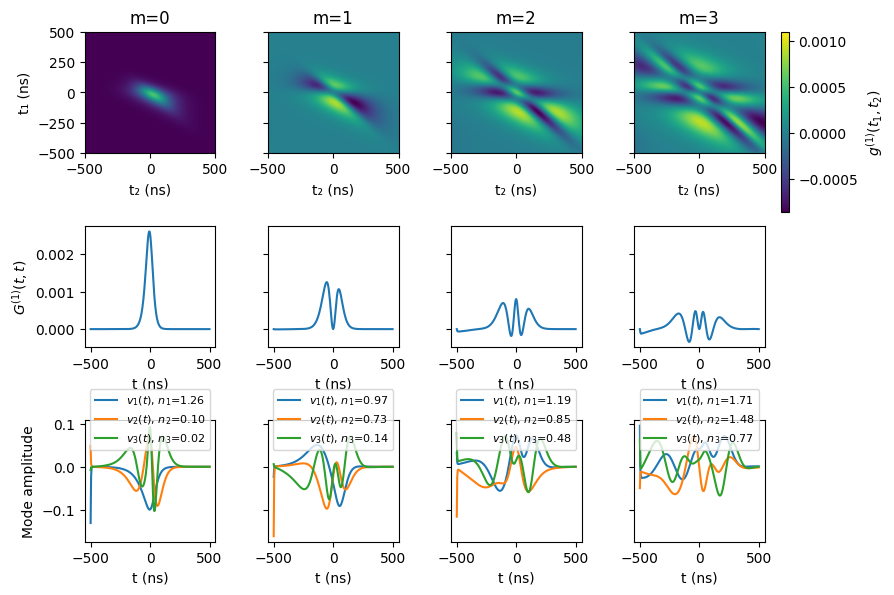

C:\Users\qipe\AppData\Local\Temp\ipykernel_14956\1575095435.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  overlap_matrix[i, j] = np.abs(np.trapz(np.conj(principal_modes[i]) * principal_modes[j], tgrid))


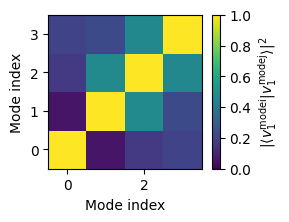

In [31]:
fig, axes = plt.subplots(3, 4, figsize=(8, 6), sharey='row')
plt.subplots_adjust(wspace=0.4, hspace=0.6, left=0.05, right=0.90, top=0.95, bottom=0.1)

principal_modes = []

for i in range(4):
    G1 = results_output[i]
    eigs, eigvecs = np.linalg.eigh(G1)
    sort_idx = np.argsort(eigs)[::-1]
    eigvecs = eigvecs[:, sort_idx]
    eigs = eigs[sort_idx]
    eigs_frac = eigs / np.sum(eigs)

    im = axes[0, i].imshow(
        G1.real,
        extent=[tgrid[0], tgrid[-1], tgrid[0], tgrid[-1]],
        origin="lower",
        aspect="auto"
    )
    axes[0, i].set_title(f"m={i}")
    axes[0, i].set_xlabel("t₂ (ns)")
    if i == 0:
        axes[0, i].set_ylabel("t₁ (ns)")

    diag_vals = np.real(np.diag(G1))
    axes[1, i].plot(tgrid, diag_vals, color='tab:blue')
    axes[1, i].set_xlabel("t (ns)")
    if i == 0:
        axes[1, i].set_ylabel(r"$G^{(1)}(t,t)$")

    lines = []
    labels = []
    for k in range(min(3, len(eigs))):
        v = eigvecs[:, k]
        v_norm = v / np.sqrt(np.trapz(np.abs(v)**2, tgrid))
        line, = axes[2, i].plot(tgrid, np.real(v_norm))
        lines.append(line)
        labels.append(f"$v_{{{k+1}}}(t)$, $n_{{{k+1}}}$={eigs_frac[k]:.2f}")

    axes[2, i].legend(handles=lines, labels=labels, fontsize=8,
                      loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=1)
    axes[2, i].set_xlabel("t (ns)")
    if i == 0:
        axes[2, i].set_ylabel("Mode amplitude")

    principal_modes.append(eigvecs[:, 0] / np.sqrt(np.trapz(np.abs(eigvecs[:, 0])**2, tgrid)))

cbar_ax = fig.add_axes([0.92, 0.65, 0.01, 0.3])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r"$g^{(1)}(t_1, t_2)$")

plt.show()

N_modes = len(principal_modes)
overlap_matrix = np.zeros((N_modes, N_modes), dtype=float)

for i in range(N_modes):
    for j in range(N_modes):
        overlap_matrix[i, j] = np.abs(np.trapz(np.conj(principal_modes[i]) * principal_modes[j], tgrid))

fig2, ax2 = plt.subplots(figsize=(2.5, 2.))
im2 = ax2.imshow(overlap_matrix**2, origin='lower', cmap='viridis', vmin=0, vmax=1)
cbar2 = fig2.colorbar(im2)
cbar2.set_label(r"$|\langle v_1^\mathrm{mode i} | v_1^\mathrm{mode j} \rangle|^2$")
ax2.set_xlabel("Mode index")
ax2.set_ylabel("Mode index")
plt.show()


10.1%. Run time:   0.00s. Est. time left: 00:00:00:00
20.1%. Run time:   0.01s. Est. time left: 00:00:00:00
30.2%. Run time:   0.01s. Est. time left: 00:00:00:00
40.2%. Run time:   0.02s. Est. time left: 00:00:00:00


50.3%. Run time:   0.02s. Est. time left: 00:00:00:00
60.3%. Run time:   0.03s. Est. time left: 00:00:00:00
70.4%. Run time:   0.03s. Est. time left: 00:00:00:00
80.4%. Run time:   0.04s. Est. time left: 00:00:00:00
90.5%. Run time:   0.04s. Est. time left: 00:00:00:00
100.0%. Run time:   0.05s. Est. time left: 00:00:00:00


c:\Users\qipe\Documents\qutip_simulation\.venv\Lib\site-packages\qutip\solver\solver_base.py:460: FutureWarning: "progress_bar" is now included in options:
 Use `options={"progress_bar": False / True / "tqdm" / "enhanced"}`
  warnings.warn(


Total run time:   0.05s


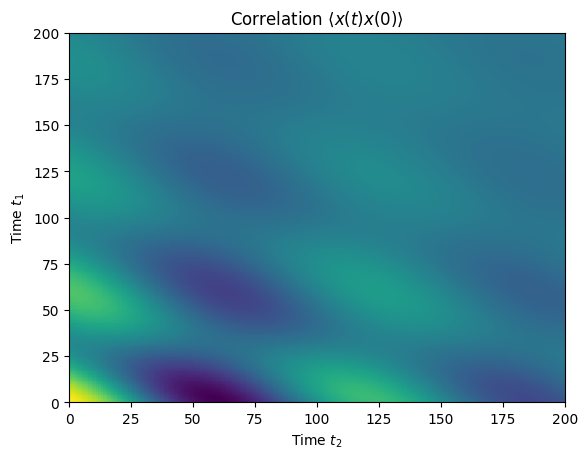

In [17]:
times = np.linspace(0, 10.0, 200)
a = qutip.destroy(10)
x = a.dag() + a
H = a.dag() * a
alpha = 2.5
rho0 = qutip.coherent_dm(10, alpha)

result = qt.mesolve(H, rho0, times,  [np.sqrt(0.25) * a], e_ops=[x * x],  options=options, progress_bar=True)
n_meso = result.expect[0]


corr = qutip.correlation_2op_2t(H, rho0, times, times, [np.sqrt(0.25) * a], x, x)

plt.pcolor(np.real(corr))
plt.xlabel(r'Time $t_2$')
plt.ylabel(r'Time $t_1$')
plt.title(r'Correlation $\left<x(t)x(0)\right>$')
plt.show()

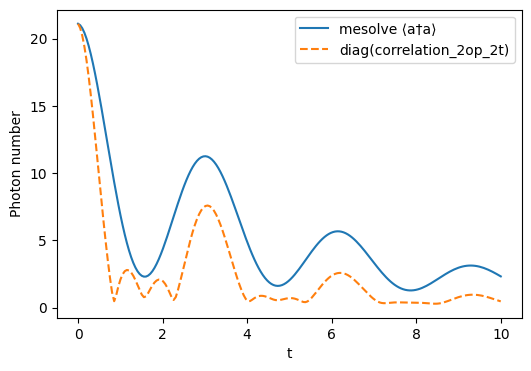

差の最大値: 9.08134091420408


In [18]:
# 対角線を取得
n_corr = np.abs(np.diag(corr))

# ---------------------------
# プロット比較
# ---------------------------
plt.figure(figsize=(6, 4))
plt.plot(times, n_meso, label="mesolve ⟨a†a⟩")
plt.plot(times, n_corr, "--", label="diag(correlation_2op_2t)")
plt.xlabel("t")
plt.ylabel("Photon number")
plt.legend()
plt.show()

# 一致を確認
print("差の最大値:", np.max(np.abs(n_meso - n_corr)))